# Panel Construction & Preliminary Analysis
## Port × HS4 × Month — U.S. Imports (2010–2025)

This notebook:
1. Loads raw Census trade data (16 annual parquet files) and the NOAA combined storm events file.
2. Runs sanity checks on both datasets.
3. Builds a Port × HS4 × Month panel by joining storm indicators (mapped from state → port) onto import observations.
4. Analyses missing values and panel coverage.
5. Runs a preliminary event study around Hurricane Harvey (August 2017) using Houston and Galveston import volumes.


In [29]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import polars as pl

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})


def find_project_root(start: Path | None = None) -> Path:
    candidate = (start or Path.cwd()).resolve()
    for path in (candidate, *candidate.parents):
        if (path / "pyproject.toml").exists():
            return path
    raise FileNotFoundError("Could not find pyproject.toml")


PROJECT_ROOT = find_project_root()
CENSUS_DIR   = PROJECT_ROOT / "data" / "raw" / "census"
NOAA_DIR     = PROJECT_ROOT / "data" / "raw" / "noaa"
INTERIM_DIR  = PROJECT_ROOT / "data" / "interim"
FIGURES_DIR  = PROJECT_ROOT / "outputs" / "figures"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

STUDY_YEARS = range(2013, 2026)   # 2010–2025 inclusive (16 years)

print(f"Project root : {PROJECT_ROOT}")
print(f"Census dir   : {CENSUS_DIR}")
print(f"NOAA dir     : {NOAA_DIR}")
print(f"Study period : {min(STUDY_YEARS)}–{max(STUDY_YEARS)}")


Project root : /Users/wenyi/Documents/ChatGPT/supply-chain-resilience
Census dir   : /Users/wenyi/Documents/ChatGPT/supply-chain-resilience/data/raw/census
NOAA dir     : /Users/wenyi/Documents/ChatGPT/supply-chain-resilience/data/raw/noaa
Study period : 2013–2025


## 1. Load Raw Data

In [31]:
# Load per-year Census parquet files and concatenate
census_frames = []
for year in STUDY_YEARS:
    matches = list(CENSUS_DIR.glob(f"census_imports_porths_hs4_country_expanded_53ports_{year}_*.parquet"))
    if matches:
        census_frames.append(pl.read_parquet(matches[0]))
    else:
        print(f"WARNING: No census file found for {year}")

imports_country_raw = pl.concat(census_frames, how="diagonal_relaxed")

# The country-detail files retain both individual partners and CTY_CODE='-' totals.
# Keep the total rows for the main Port × HS4 × Month panel; use CTY_CODE != '-'
# separately when constructing supplier-country concentration measures.
imports_raw = (
    imports_country_raw
    .filter((pl.col("COMM_LVL") == "HS4"))
    .sort(["time", "PORT", "I_COMMODITY"])
)

print(f"Census country-detail shape : {imports_country_raw.shape}")
print(f"Individual-country rows     : {imports_country_raw.filter(pl.col('CTY_CODE') != '-').height:,}")
print(f"All-country panel shape     : {imports_raw.shape}")
print(f"Time range           : {imports_raw['time'].min()} → {imports_raw['time'].max()}")
print(f"Unique ports         : {imports_raw['PORT'].n_unique()}")
print(f"Unique HS4 codes     : {imports_raw['I_COMMODITY'].n_unique()}")
print(f"Unique CTY_CODE      : {imports_raw['CTY_CODE'].n_unique()}")

imports_raw.head(3)


Census country-detail shape : (32021578, 16)
Individual-country rows     : 28,422,046
All-country panel shape     : (32021578, 16)
Time range           : 2013-01 → 2025-12
Unique ports         : 53
Unique HS4 codes     : 1237
Unique CTY_CODE      : 235


YEAR,MONTH,PORT,PORT_NAME,CTY_CODE,CTY_NAME,I_COMMODITY,I_COMMODITY_LDESC,COMM_LVL,SUMMARY_LVL,GEN_VAL_MO,VES_VAL_MO,VES_WGT_MO,CNT_VAL_MO,CNT_WGT_MO,time
str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,str
"""2013""","""01""","""0401""","""BOSTON, MA""","""-""","""TOTAL FOR ALL COUNTRIES""","""0303""","""FISH, FROZEN, EXCLUDING FISH F…","""HS4""","""DET""",7841947,7841947,2564226,7841947,2564226,"""2013-01"""
"""2013""","""01""","""0401""","""BOSTON, MA""","""4039""","""NORWAY""","""0303""","""FISH, FROZEN, EXCLUDING FISH F…","""HS4""","""DET""",7768717,7768717,2527186,7768717,2527186,"""2013-01"""
"""2013""","""01""","""0401""","""BOSTON, MA""","""5700""","""CHINA""","""0303""","""FISH, FROZEN, EXCLUDING FISH F…","""HS4""","""DET""",73230,73230,37040,73230,37040,"""2013-01"""


In [32]:
noaa_file = next(NOAA_DIR.glob("noaa_storm_events_*.parquet"), None)
if noaa_file is None:
    raise FileNotFoundError(f"No NOAA storm events parquet found in {NOAA_DIR}")

storms_raw = (
    pl.read_parquet(noaa_file)
    .filter(pl.col("month").dt.year().is_between(2010, 2025))
    .with_columns(pl.col("month").dt.strftime("%Y-%m").alias("time"))
)

print(f"NOAA storms shape    : {storms_raw.shape}")
print(f"Time range           : {storms_raw['time'].min()} → {storms_raw['time'].max()}")
print(f"Event types          : {sorted(storms_raw['event_type'].unique().to_list())}")
print(f"Unique states        : {storms_raw['state'].n_unique()}")
storms_raw.head(3)


NOAA storms shape    : (8499, 55)
Time range           : 2010-01 → 2025-12
Event types          : ['Coastal Flood', 'Hurricane (Typhoon)', 'Storm Surge/Tide', 'Tropical Storm']
Unique states        : 35


begin_yearmonth,begin_day,begin_time,end_yearmonth,end_day,end_time,episode_id,event_id,state,state_fips,year,month_name,event_type,cz_type,cz_fips,cz_name,wfo,begin_date_time,cz_timezone,end_date_time,injuries_direct,injuries_indirect,deaths_direct,deaths_indirect,damage_property,damage_crops,source,magnitude,magnitude_type,flood_cause,category,tor_f_scale,tor_length,tor_width,tor_other_wfo,tor_other_cz_state,tor_other_cz_fips,tor_other_cz_name,begin_range,begin_azimuth,begin_location,end_range,end_azimuth,end_location,begin_lat,begin_lon,end_lat,end_lon,episode_narrative,event_narrative,data_source,month,property_damage_usd,crop_damage_usd,time
i64,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,str,str,str,i64,str,str,str,str,str,i64,i64,i64,i64,str,str,str,f64,str,str,str,str,f64,f64,str,str,i64,str,f64,str,str,f64,str,str,f64,f64,f64,f64,str,str,str,date,f64,f64,str
201001,25,1223,201001,25,1520,36157,209676,"""MARYLAND""",24,2010,"""January""","""Coastal Flood""","""Z""",14,"""ANNE ARUNDEL""","""LWX""","""25-JAN-10 12:23:00""","""EST-5""","""25-JAN-10 15:20:00""",0,0,0,0,null,null,"""Public""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""A persistent onshore flow lead…","""Coastal flooding was reported …","""CSV""",2010-01-01,null,null,"""2010-01"""
201001,25,1136,201001,25,1705,36157,209677,"""MARYLAND""",24,2010,"""January""","""Coastal Flood""","""Z""",11,"""SOUTHERN BALTIMORE""","""LWX""","""25-JAN-10 11:36:00""","""EST-5""","""25-JAN-10 17:05:00""",0,0,0,0,"""10.00K""",null,"""Emergency Manager""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""A persistent onshore flow lead…","""High water rescues were report…","""CSV""",2010-01-01,10000.0,null,"""2010-01"""
201001,27,253,201001,27,1059,36158,209678,"""DISTRICT OF COLUMBIA""",11,2010,"""January""","""Coastal Flood""","""Z""",1,"""DISTRICT OF COLUMBIA""","""LWX""","""27-JAN-10 02:53:00""","""EST-5""","""27-JAN-10 10:59:00""",0,0,0,0,null,null,"""Other Federal Agency""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""Heavy amounts of rain over the…","""Washington Harbor had to raise…","""CSV""",2010-01-01,null,null,"""2010-01"""


## 2. Sanity Checks

In [33]:
# ── Census sanity checks ──────────────────────────────────────────────────────

print("=== Row counts by year ===")
print(
    imports_raw
    .with_columns(pl.col("time").str.slice(0, 4).cast(pl.Int32).alias("year"))
    .group_by("year").agg(pl.len().alias("rows"))
    .sort("year")
)

print("\n=== Missing values ===")
print(imports_raw.null_count())

print("\n=== GEN_VAL_MO summary (USD) ===")
print(imports_raw.select("GEN_VAL_MO").describe())

n_zero = imports_raw.filter(pl.col("GEN_VAL_MO").is_null() | (pl.col("GEN_VAL_MO") <= 0)).height
print(f"\nRows with GEN_VAL_MO null or ≤ 0 : {n_zero:,}  ({n_zero / imports_raw.height * 100:.2f}%)")

print("\n=== Unique ports per year ===")
print(
    imports_raw
    .with_columns(pl.col("time").str.slice(0, 4).alias("year"))
    .group_by("year").agg(pl.col("PORT").n_unique().alias("n_ports"))
    .sort("year")
)


=== Row counts by year ===
shape: (13, 2)
┌──────┬─────────┐
│ year ┆ rows    │
│ ---  ┆ ---     │
│ i32  ┆ u32     │
╞══════╪═════════╡
│ 2013 ┆ 2186232 │
│ 2014 ┆ 2247051 │
│ 2015 ┆ 2323571 │
│ 2016 ┆ 2331119 │
│ 2017 ┆ 2392110 │
│ …    ┆ …       │
│ 2021 ┆ 2567848 │
│ 2022 ┆ 2629652 │
│ 2023 ┆ 2602479 │
│ 2024 ┆ 2633247 │
│ 2025 ┆ 2711782 │
└──────┴─────────┘

=== Missing values ===
shape: (1, 16)
┌──────┬───────┬──────┬───────────┬───┬────────────┬────────────┬────────────┬──────┐
│ YEAR ┆ MONTH ┆ PORT ┆ PORT_NAME ┆ … ┆ VES_WGT_MO ┆ CNT_VAL_MO ┆ CNT_WGT_MO ┆ time │
│ ---  ┆ ---   ┆ ---  ┆ ---       ┆   ┆ ---        ┆ ---        ┆ ---        ┆ ---  │
│ u32  ┆ u32   ┆ u32  ┆ u32       ┆   ┆ u32        ┆ u32        ┆ u32        ┆ u32  │
╞══════╪═══════╪══════╪═══════════╪═══╪════════════╪════════════╪════════════╪══════╡
│ 0    ┆ 0     ┆ 0    ┆ 0         ┆ … ┆ 0          ┆ 0          ┆ 0          ┆ 0    │
└──────┴───────┴──────┴───────────┴───┴────────────┴────────────┴────────────┴──

In [34]:
# ── NOAA sanity checks ────────────────────────────────────────────────────────

print("=== Event counts by year and type ===")
event_pivot = (
    storms_raw
    .group_by(["year", "event_type"])
    .agg(pl.len().alias("n"))
    .sort(["year", "event_type"])
    .pivot("event_type", index="year", values="n", aggregate_function="sum")
    .sort("year")
)
print(event_pivot)

print("\n=== Missing values in NOAA data ===")
print(storms_raw.null_count())

damage_events = storms_raw.filter(
    pl.col("property_damage_usd").is_not_null() & (pl.col("property_damage_usd") > 0)
)
print(f"\nEvents with property_damage_usd > 0 : {damage_events.height:,}")
print(damage_events.select("property_damage_usd").describe())

print("\n=== Top 10 states by event count ===")
print(
    storms_raw.group_by("state")
    .agg(pl.len().alias("n_events"))
    .sort("n_events", descending=True)
    .head(10)
)


=== Event counts by year and type ===
shape: (16, 5)
┌──────┬───────────────┬─────────────────────┬──────────────────┬────────────────┐
│ year ┆ Coastal Flood ┆ Hurricane (Typhoon) ┆ Storm Surge/Tide ┆ Tropical Storm │
│ ---  ┆ ---           ┆ ---                 ┆ ---              ┆ ---            │
│ i64  ┆ u32           ┆ u32                 ┆ u32              ┆ u32            │
╞══════╪═══════════════╪═════════════════════╪══════════════════╪════════════════╡
│ 2010 ┆ 102           ┆ 2                   ┆ 25               ┆ 41             │
│ 2011 ┆ 106           ┆ 16                  ┆ 82               ┆ 466            │
│ 2012 ┆ 269           ┆ 33                  ┆ 62               ┆ 190            │
│ 2013 ┆ 104           ┆ 2                   ┆ 4                ┆ 96             │
│ 2014 ┆ 106           ┆ 6                   ┆ 2                ┆ 31             │
│ …    ┆ …             ┆ …                   ┆ …                ┆ …              │
│ 2021 ┆ 214           ┆ 39       

## 3. Build Port × HS4 × Month Panel

Each NOAA storm event is tagged with a state. We map coastal states to the 53-port Census study universe (core gateways plus regional alternatives) to create a `PORT × month` storm indicator, then left-join it onto the import panel. This state-level indicator is a broad screening measure; the causal event study should later replace it with port-specific storm exposure and operational-disruption validation.

In [35]:
# Coastal state → Census Schedule D port-code mapping.
# This matches the expanded 53-port universe in census_download_colab.ipynb.
# Reference: https://www.census.gov/foreign-trade/schedules/d/distcode.html
STATE_PORT_MAP: dict[str, list[str]] = {
    "MASSACHUSETTS":  ["0401"],
    "RHODE ISLAND":   ["0502"],
    "CALIFORNIA":     ["2501", "2704", "2709", "2713", "2811", "2812"],
    "OREGON":         ["2904"],
    "WASHINGTON":     ["2905", "2908", "3001", "3002"],
    "NEW YORK":       ["1001"],
    "NEW JERSEY":     ["1003"],
    "PENNSYLVANIA":   ["1101"],
    "DELAWARE":       ["1103"],
    "MARYLAND":       ["1303"],
    "VIRGINIA":       ["1401"],
    "NORTH CAROLINA": ["1501", "1511"],
    "SOUTH CAROLINA": ["1601"],
    "GEORGIA":        ["1701", "1703"],
    "FLORIDA":        [
        "1801", "1803", "1805", "1816", "1818",
        "1819", "1821", "5201", "5203", "5204",
    ],
    "ALABAMA":        ["1901"],
    "MISSISSIPPI":    ["1902", "1903"],
    "LOUISIANA":      ["2002", "2004", "2010", "2017"],
    "TEXAS":          [
        "2101", "2102", "2103", "2104", "5301",
        "5306", "5310", "5311", "5312", "5313",
    ],
    "HAWAII":         ["3201"],
    "PUERTO RICO":    ["4909"],
}

MAPPED_PORTS = [port for ports in STATE_PORT_MAP.values() for port in ports]
assert len(MAPPED_PORTS) == 53, f'Expected 53 mapped ports, found {len(MAPPED_PORTS)}'
assert len(MAPPED_PORTS) == len(set(MAPPED_PORTS)), 'A port is mapped to multiple states'
assert all(len(port) == 4 and port.isdigit() for port in MAPPED_PORTS)
print(f'Mapped {len(MAPPED_PORTS)} Census ports across {len(STATE_PORT_MAP)} coastal states/territories')

state_port_df = pl.DataFrame(
    [{"state": state, "PORT": port}
     for state, ports in STATE_PORT_MAP.items()
     for port in ports]
)

# Aggregate storm events by PORT × month
storms_by_port = (
    storms_raw
    .with_columns(pl.col("state").str.to_uppercase())
    .join(state_port_df, on="state", how="inner")
    .group_by(["PORT", "time"])
    .agg(
        pl.len().alias("n_storm_events"),
        pl.col("property_damage_usd").sum().alias("total_property_damage_usd"),
        pl.col("crop_damage_usd").sum().alias("total_crop_damage_usd"),
    )
    .with_columns(pl.lit(1).cast(pl.Int8).alias("storm_month"))
    .sort(["PORT", "time"])
)

print(f"PORT × month combinations with storms : {storms_by_port.height:,}")
storms_by_port.head(5)


Mapped 53 Census ports across 21 coastal states/territories
PORT × month combinations with storms : 2,200


PORT,time,n_storm_events,total_property_damage_usd,total_crop_damage_usd,storm_month
str,str,u32,f64,f64,i8
"""0401""","""2010-01""",4,0.0,0.0,1
"""0401""","""2010-02""",2,0.0,0.0,1
"""0401""","""2010-03""",7,20000.0,0.0,1
"""0401""","""2010-04""",1,0.0,0.0,1
"""0401""","""2010-09""",2,20000.0,0.0,1


In [36]:
# Left-join storm indicators onto the import panel
panel = (
    imports_raw
    .join(storms_by_port, on=["time", "PORT"], how="left")
    .with_columns(
        pl.col("storm_month").fill_null(0).cast(pl.Int8),
        pl.col("n_storm_events").fill_null(0).cast(pl.Int32),
        pl.col("total_property_damage_usd").fill_null(0.0),
        pl.col("total_crop_damage_usd").fill_null(0.0),
    )
    .sort(["time", "PORT", "I_COMMODITY"])
)

print(f"Panel shape                  : {panel.shape}")
print(f"Time range                   : {panel['time'].min()} → {panel['time'].max()}")
print(f"Unique PORT × HS4 × month    : {panel.n_unique(subset=['time', 'PORT', 'I_COMMODITY']):,}")
print(f"Storm-month observations     : {panel['storm_month'].sum():,}")
print(f"  (% of all observations)    : {panel['storm_month'].mean() * 100:.2f}%")
panel.head(3)


Panel shape                  : (32021578, 20)
Time range                   : 2013-01 → 2025-12
Unique PORT × HS4 × month    : 3,599,532
Storm-month observations     : 7,884,115
  (% of all observations)    : 24.62%


YEAR,MONTH,PORT,PORT_NAME,CTY_CODE,CTY_NAME,I_COMMODITY,I_COMMODITY_LDESC,COMM_LVL,SUMMARY_LVL,GEN_VAL_MO,VES_VAL_MO,VES_WGT_MO,CNT_VAL_MO,CNT_WGT_MO,time,n_storm_events,total_property_damage_usd,total_crop_damage_usd,storm_month
str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,str,i32,f64,f64,i8
"""2013""","""01""","""0401""","""BOSTON, MA""","""-""","""TOTAL FOR ALL COUNTRIES""","""0303""","""FISH, FROZEN, EXCLUDING FISH F…","""HS4""","""DET""",7841947,7841947,2564226,7841947,2564226,"""2013-01""",0,0.0,0.0,0
"""2013""","""01""","""0401""","""BOSTON, MA""","""4039""","""NORWAY""","""0303""","""FISH, FROZEN, EXCLUDING FISH F…","""HS4""","""DET""",7768717,7768717,2527186,7768717,2527186,"""2013-01""",0,0.0,0.0,0
"""2013""","""01""","""0401""","""BOSTON, MA""","""5700""","""CHINA""","""0303""","""FISH, FROZEN, EXCLUDING FISH F…","""HS4""","""DET""",73230,73230,37040,73230,37040,"""2013-01""",0,0.0,0.0,0


In [37]:
out_path = INTERIM_DIR / "panel_port_hs4_month_2013_2025.parquet"
panel.write_parquet(out_path)
print(f"Panel saved → {out_path}")
print(f"File size    : {out_path.stat().st_size / 1e6:.1f} MB")


Panel saved → /Users/wenyi/Documents/ChatGPT/supply-chain-resilience/data/interim/panel_port_hs4_month_2013_2025.parquet
File size    : 483.0 MB


## 4. Missing Value Analysis

In [38]:
# ── Panel null counts ─────────────────────────────────────────────────────────
print("=== Panel null counts ===")
print(panel.null_count())

# Import value completeness
n_null_val = panel.filter(pl.col("GEN_VAL_MO").is_null()).height
print(f"\nRows with null GEN_VAL_MO    : {n_null_val:,}  ({n_null_val / panel.height * 100:.2f}%)")

# Months per port: check for gaps in the time series
print("\n=== Expected vs. observed months per port ===")
expected_months = len(STUDY_YEARS) * 12
port_month_counts = (
    panel
    .select(["PORT", "PORT_NAME", "time"])
    .unique()
    .group_by(["PORT", "PORT_NAME"])
    .agg(pl.len().alias("observed_months"))
    .with_columns((pl.col("observed_months") / expected_months * 100).round(1).alias("coverage_pct"))
    .sort("PORT")
)
print(port_month_counts)

# Storm-month coverage by port
print("\n=== Storm-month coverage by port ===")
port_storm = (
    panel
    .select(["PORT", "PORT_NAME", "time", "storm_month"])
    .unique()
    .group_by(["PORT", "PORT_NAME"])
    .agg(
        pl.len().alias("total_port_months"),
        pl.col("storm_month").max().alias("has_storm_data"),
        pl.col("storm_month").sum().alias("storm_months"),
    )
    .with_columns(
        (pl.col("storm_months") / pl.col("total_port_months") * 100).round(2).alias("storm_pct")
    )
    .sort("storm_pct", descending=True)
)
print(port_storm)


=== Panel null counts ===
shape: (1, 20)
┌──────┬───────┬──────┬───────────┬───┬───────────────┬───────────────┬──────────────┬─────────────┐
│ YEAR ┆ MONTH ┆ PORT ┆ PORT_NAME ┆ … ┆ n_storm_event ┆ total_propert ┆ total_crop_d ┆ storm_month │
│ ---  ┆ ---   ┆ ---  ┆ ---       ┆   ┆ s             ┆ y_damage_usd  ┆ amage_usd    ┆ ---         │
│ u32  ┆ u32   ┆ u32  ┆ u32       ┆   ┆ ---           ┆ ---           ┆ ---          ┆ u32         │
│      ┆       ┆      ┆           ┆   ┆ u32           ┆ u32           ┆ u32          ┆             │
╞══════╪═══════╪══════╪═══════════╪═══╪═══════════════╪═══════════════╪══════════════╪═════════════╡
│ 0    ┆ 0     ┆ 0    ┆ 0         ┆ … ┆ 0             ┆ 0             ┆ 0            ┆ 0           │
└──────┴───────┴──────┴───────────┴───┴───────────────┴───────────────┴──────────────┴─────────────┘

Rows with null GEN_VAL_MO    : 0  (0.00%)

=== Expected vs. observed months per port ===
shape: (53, 4)
┌──────┬────────────────────┬─────────────────

## 5. Event Study: Hurricane Harvey (August 2017)

Hurricane Harvey made landfall near Rockport, TX on 25 August 2017 — one of the costliest Atlantic hurricanes on record. Houston (port 5301) and Galveston (5310) are the two major Census ports in Texas. We plot total monthly import values for an 11-month window (January–November 2017) to visualise the before/after pattern.

In [39]:
HARVEY_MONTH  = "2017-08"
HARVEY_PORTS  = {"5301": "Houston, TX", "5310": "Galveston, TX"}

# 11-month window: Jan 2017 – Nov 2017
WINDOW = [f"2017-{m:02d}" for m in range(1, 12)]

# Confirm Harvey appears in the NOAA data
print("=== NOAA events in Texas, August 2017 ===")
texas_harvey = (
    storms_raw
    .filter((pl.col("state") == "TEXAS") & (pl.col("time") == HARVEY_MONTH))
    .select(["event_type", "cz_name", "property_damage_usd"])
    .sort("property_damage_usd", descending=True, nulls_last=True)
)
print(texas_harvey)

# Aggregate across all HS4 codes for each target port × month
harvey_data = (
    panel
    .filter(pl.col("PORT").is_in(list(HARVEY_PORTS.keys())) & pl.col("time").is_in(WINDOW))
    .group_by(["time", "PORT", "PORT_NAME"])
    .agg(
        pl.col("GEN_VAL_MO").sum().alias("total_import_value"),
        pl.col("n_storm_events").max().alias("n_storm_events"),
        pl.col("storm_month").max().alias("is_storm_month"),
    )
    .sort(["PORT", "time"])
)

print(f"\nHarvey window shape: {harvey_data.shape}")
print(harvey_data.select(["time", "PORT", "PORT_NAME", "total_import_value", "is_storm_month"]))


=== NOAA events in Texas, August 2017 ===
shape: (50, 3)
┌─────────────────────┬───────────┬─────────────────────┐
│ event_type          ┆ cz_name   ┆ property_damage_usd │
│ ---                 ┆ ---       ┆ ---                 │
│ str                 ┆ str       ┆ f64                 │
╞═════════════════════╪═══════════╪═════════════════════╡
│ Hurricane (Typhoon) ┆ ARANSAS   ┆ 1.7500e9            │
│ Tropical Storm      ┆ LIBERTY   ┆ 1.0000e9            │
│ Hurricane (Typhoon) ┆ NUECES    ┆ 1.0000e9            │
│ Tropical Storm      ┆ MATAGORDA ┆ 5e8                 │
│ Tropical Storm      ┆ JACKSON   ┆ 5e8                 │
│ …                   ┆ …         ┆ …                   │
│ Tropical Storm      ┆ BRAZORIA  ┆ 0.0                 │
│ Tropical Storm      ┆ HARRIS    ┆ 0.0                 │
│ Storm Surge/Tide    ┆ JEFFERSON ┆ 0.0                 │
│ Tropical Storm      ┆ JEFFERSON ┆ 0.0                 │
│ Tropical Storm      ┆ AUSTIN    ┆ null                │
└──────────────

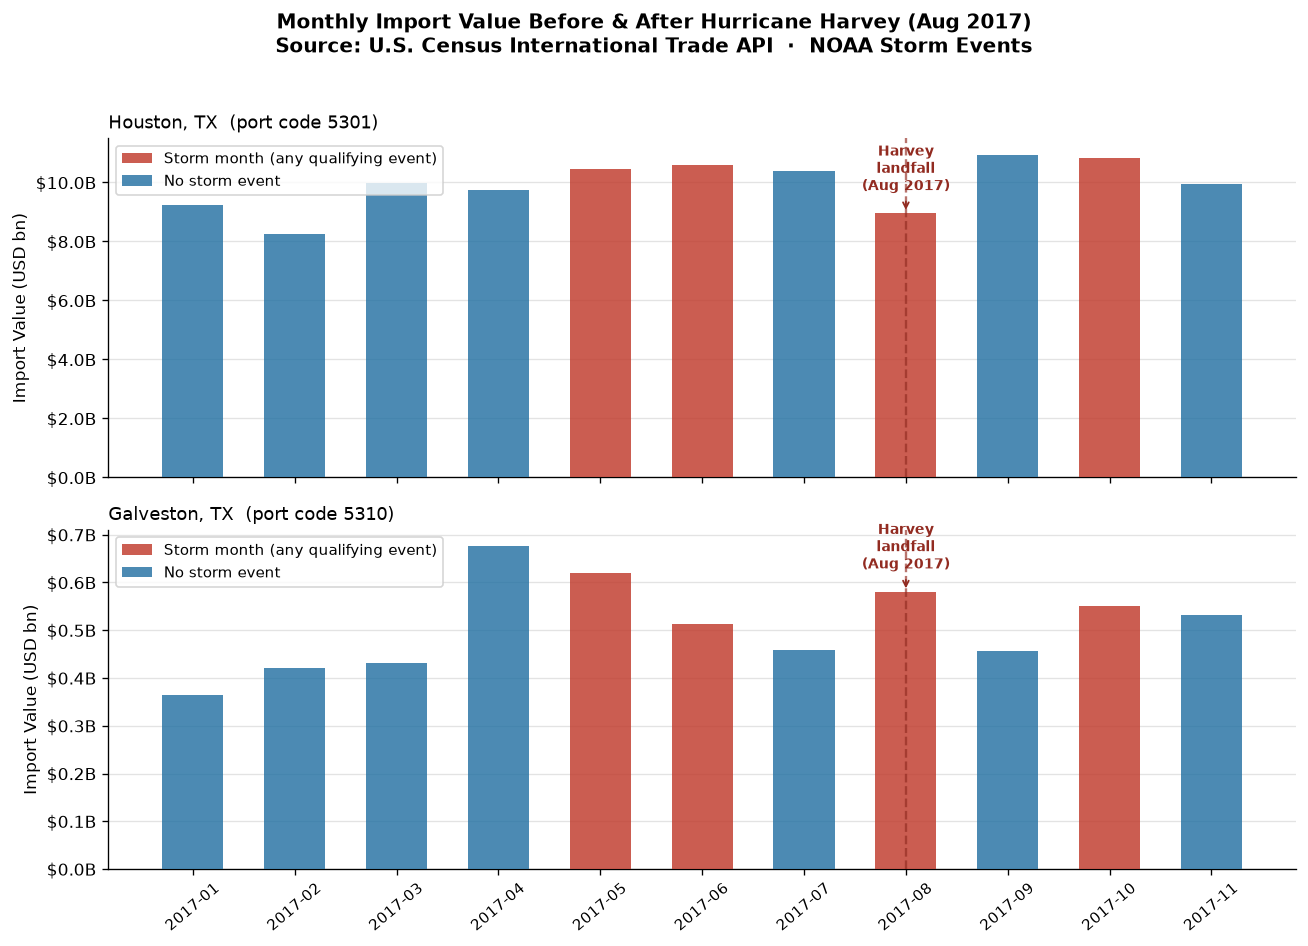

In [41]:
fig, axes = plt.subplots(len(HARVEY_PORTS), 1, figsize=(11, 8), sharex=True)
fig.suptitle(
    "Monthly Import Value Before & After Hurricane Harvey (Aug 2017)\n"
    "Source: U.S. Census International Trade API  ·  NOAA Storm Events",
    fontsize=12, fontweight="bold",
)

for ax, (port_code, port_label) in zip(axes, HARVEY_PORTS.items()):
    port_df = harvey_data.filter(pl.col("PORT") == port_code).sort("time")
    months = port_df["time"].to_list()
    values = [v / 1e9 if v is not None else 0.0 for v in port_df["total_import_value"].to_list()]
    flags  = port_df["is_storm_month"].to_list()

    colors = ["#c0392b" if f else "#2471a3" for f in flags]
    ax.bar(months, values, color=colors, alpha=0.82, width=0.6, zorder=3)

    # Dashed reference line at the Harvey month
    ax.axvline(x=HARVEY_MONTH, color="#922b21", linewidth=1.4, linestyle="--", zorder=4, alpha=0.65)

    # Annotate specifically the Harvey landfall month (2017-08)
    if HARVEY_MONTH in months:
        harvey_idx = months.index(HARVEY_MONTH)
        ax.annotate(
            "Harvey\nlandfall\n(Aug 2017)",
            xy=(months[harvey_idx], values[harvey_idx]),
            xytext=(0, 14), textcoords="offset points",
            ha="center", fontsize=8.5, color="#922b21", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#922b21", lw=1.1),
        )

    ax.set_title(f"{port_label}  (port code {port_code})", fontsize=10.5, loc="left")
    ax.set_ylabel("Import Value (USD bn)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}B"))
    ax.tick_params(axis="x", rotation=40, labelsize=9)
    ax.grid(axis="y", alpha=0.35, zorder=0)
    ax.legend(
        handles=[
            Patch(facecolor="#c0392b", alpha=0.82, label="Storm month (any qualifying event)"),
            Patch(facecolor="#2471a3", alpha=0.82, label="No storm event"),
        ],
        fontsize=9, loc="upper left",
    )

fig.tight_layout(rect=[0, 0, 1, 0.96])
# out_fig = FIGURES_DIR / "harvey_2017_port_imports.png"
# plt.savefig(out_fig, bbox_inches="tight", dpi=150)
plt.show()
# print(f"Figure saved → {out_fig}")
